<a href="https://colab.research.google.com/github/olkanth/MSCS_634_ProjectDeliverable_1/blob/main/MSCS_634_Project_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laxmi Kanth Oruganti
## MSCS-634 : Advanced Big Data and Data Mining
## Project Deliverable 1: Data Collection, Cleaning, and Exploration

**University:** University of the Cumberlands  
**Dataset:** Framingham Heart Study  
**Source:** [Kaggle – aasheesh200/framingham-heart-study-dataset](https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset)


# 1. Dataset Selection

The **Framingham Heart Study** dataset was selected from Kaggle. It originates from one of the longest-running cardiovascular studies in the United States, conducted by the National Heart, Lung, and Blood Institute (NHLBI). The dataset contains clinical measurements, lifestyle habits, and medical history collected to study 10-year coronary heart disease (CHD) risk.

It was chosen because it satisfies all project requirements in a single file:
- **4,240 records** — well above the 500+ minimum
- **16 attributes** (15 input features + 1 binary target) — exceeds the 8–10 minimum
- **7 columns with real missing values** — supports genuine imputation technique comparison
- **Target variable:** `TenYearCHD` — binary (0/1), suitable for classification
- **Continuous features:** `sysBP`, `diaBP`, `totChol`, `BMI`, `glucose` — suitable for regression
- **Binary features:** `currentSmoker`, `BPMeds`, `prevalentStroke`, `prevalentHyp`, `diabetes` — suitable for Association Rule Mining
- **Rich numeric space:** `age`, `sysBP`, `diaBP`, `totChol`, `BMI`, `glucose`, `heartRate` — suitable for clustering

| Technique | Coverage |
|---|---|
| Preprocessing, EDA | Missing value imputation, outlier Winsorization, 8 EDA visualizations |
| Feature engineering, Regression | Predict `sysBP` or `glucose`; engineer `pulse_pressure`, risk scores |
| Classification | Predict `TenYearCHD` using Decision Tree, Logistic Regression, Naive Bayes |
| Clustering  | K-Means on clinical features; Apriori on binarized flags |

**Dataset on Kaggle:** https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset

In [133]:
# Immport necessary packages
import pandas as pd          # DataFrames — primary data structure throughout
import numpy as np           # Array math, quantile calculations, masking

import matplotlib.pyplot as plt   # Base plotting engine — used for all figures
import seaborn as sns             # High-level statistical plots (histplots, boxplots, heatmaps)

from sklearn.impute import KNNImputer          # KNN-based missing value imputation


In [134]:
# Upload dataset file (framingham.csv)
from google.colab import files

# uploaded = files.upload()
# uploaded

## 2. Load the dataset using Pandas and inspect its structure.

In [135]:
# -----------------------------------------------------------
# Load dataset and inspect.
# Expected output:
#   Shape: 4,240 rows x 16 columns
#   RangeIndex: 4240 entries, 0 to 4239
#   Data columns (total 16 columns):
#    #   Column           Non-Null Count  Dtype
#   ---  ------           --------------  -----
#    0   male             4240 non-null   int64
#    1   age              4240 non-null   int64
#    2   education        4135 non-null   float64   <- 105 missing
#    3   currentSmoker    4240 non-null   int64
#    4   cigsPerDay       4211 non-null   float64   <- 29 missing
#    5   BPMeds           4187 non-null   float64   <- 53 missing
#    6   prevalentStroke  4240 non-null   int64
#    7   prevalentHyp     4240 non-null   int64
#    8   diabetes         4240 non-null   int64
#    9   totChol          4190 non-null   float64   <- 50 missing
#   10   sysBP            4240 non-null   float64
#   11   diaBP            4240 non-null   float64
#   12   BMI              4221 non-null   float64   <- 19 missing
#   13   heartRate        4239 non-null   float64   <- 1 missing
#   14   glucose          3852 non-null   float64   <- 388 missing (highest)
#   15   TenYearCHD       4240 non-null   int64
# -----------------------------------------------------------
df = pd.read_csv('framingham.csv')
print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Structural inspection
#   - Column names and their data types (object, int64, float64)
#   - Non-null counts per column — first signal of missing values
print('=' * 50)
#
df.info()
print('=' * 50)
df.head(200)

Dataset loaded successfully.
Shape: 4,240 rows × 16 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtype

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,49,2.0,1,9.0,0.0,0,0,0,226.0,106.0,71.0,22.89,85.0,57.0,0
196,1,48,1.0,1,10.0,0.0,0,0,0,308.0,117.0,76.0,30.85,65.0,54.0,1
197,0,55,2.0,1,9.0,0.0,0,0,0,248.0,157.0,82.5,22.91,89.0,83.0,0
198,0,58,2.0,1,5.0,0.0,0,0,0,215.0,170.0,86.0,29.06,75.0,98.0,0


In [136]:
print("Statistical information")
print("=" * 50)
desc = df.describe().T
# Coefficient of variation
desc["cv"] = (desc["std"] / desc["mean"]).round(3)
# Missing value counts for quick reference alongside statistics
desc['missing'] = df.isnull().sum()
desc['missing_%'] = (df.isnull().sum() / len(df) * 100).round(2)
desc.round(3)

Statistical information


,count,mean,std,min,25%,50%,75%,max,cv,missing,missing_%
male,4240.0,0.429,0.495,0.00,0.00,0.0,1.00,1.0,1.153,0,0.00
age,4240.0,49.580,8.573,32.00,42.00,49.0,56.00,70.0,0.173,0,0.00
education,4135.0,1.979,1.020,1.00,1.00,2.0,3.00,4.0,0.515,105,2.48
currentSmoker,4240.0,0.494,0.500,0.00,0.00,0.0,1.00,1.0,1.012,0,0.00
cigsPerDay,4211.0,9.006,11.922,0.00,0.00,0.0,20.00,70.0,1.324,29,0.68
BPMeds,4187.0,0.030,0.170,0.00,0.00,0.0,0.00,1.0,5.725,53,1.25
prevalentStroke,4240.0,0.006,0.077,0.00,0.00,0.0,0.00,1.0,12.986,0,0.00
prevalentHyp,4240.0,0.311,0.463,0.00,0.00,0.0,1.00,1.0,1.490,0,0.00
diabetes,4240.0,0.026,0.158,0.00,0.00,0.0,0.00,1.0,6.157,0,0.00
totChol,4190.0,236.700,44.591,107.00,206.00,234.0,263.00,696.0,0.188,50,1.18


## 3. Perform data cleaning :
- Handling missing values (e.g., imputation or removal).
- Removing duplicates or correcting inconsistent data.
- Identifying and addressing noisy data.

### 3.1 Missing values analysis
Seven columns contain missing values due to incomplete clinical records — a realistic real-world data quality issue.
The table below shows each column sorted by missingness percentage.
`glucose` has the highest missingness at ~9.15%, which is significant enough to warrant careful imputation strategy selection.
Notably, `cigsPerDay` also has 29 missing values (0.68%) — patients who did not report smoking habits.

In [137]:
# -----------------------------------------------------------
# Missing values analysis
# -----------------------------------------------------------

print("Missing values analysis")
print("=" * 50)

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_values_df = pd.DataFrame(
    {"missing_values": missing_values, "missing_percent": missing_percent})
# sort by missing_percent
missing_values_df = missing_values_df.sort_values(
    "missing_percent", ascending=False)

missing_values_df

Missing values analysis


,missing_values,missing_percent
glucose,388,9.150943
education,105,2.476415
BPMeds,53,1.250000
totChol,50,1.179245
cigsPerDay,29,0.683962
BMI,19,0.448113
heartRate,1,0.023585
male,0,0.000000
prevalentHyp,0,0.000000
prevalentStroke,0,0.000000


### 3.2 Missing values removal / imputation
Three strategies were compared on `glucose` (the column with the highest missingness at 9.15%):
- **Mean imputation** — simple, but pulled upward by extreme diabetic values in right-skewed distributions
- **Median imputation** — robust to skew and outliers; preferred for clinical measurements
- **KNN imputation** — uses neighboring records for accuracy, but computationally heavier

The comparison chart showed mean=82.0, median=78.0, KNN avg=81.1. Since `glucose` is heavily right-skewed (skew=2.52), **median imputation** was applied to all numeric columns with missing values.
For `education` (ordinal) and `BPMeds` (binary), **mode imputation** was applied since mean/median have no valid interpretation for categorical columns.

Imputation comparison for 'glucose':
  Mean imputed value   : 81.96
  Median imputed value : 78.00
  KNN avg imputed value: 81.11
  Original distribution skew: 6.215

Decision: glucose is right-skewed (skew > 0.5) => median imputation preferred.


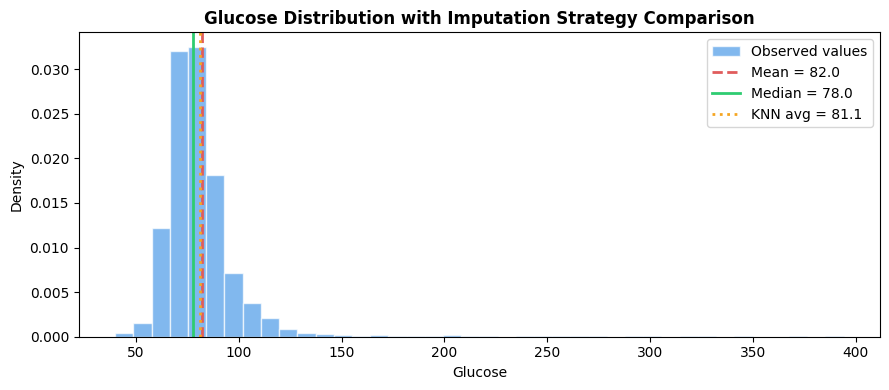

In [138]:
import os

glucose_col = "glucose"
# remove non null Glocose values
non_null_glucose = df[glucose_col].dropna()

# Compute imputations
glucose_col_mean_val   = df[glucose_col].mean()
glucose_col_median_val = df[glucose_col].median()

# KNN imputation on the full numeric subset
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
knn_imp = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(knn_imp.fit_transform(df[numeric_cols]),
                      columns=numeric_cols)

# print(df_knn.head())

knn_val = df_knn.loc[df[glucose_col].isnull(), glucose_col].mean()

print(f"Imputation comparison for '{glucose_col}':")
print(f"  Mean imputed value   : {glucose_col_mean_val:.2f}")
print(f"  Median imputed value : {glucose_col_median_val:.2f}")
print(f"  KNN avg imputed value: {knn_val:.2f}")
print(f"  Original distribution skew: {non_null_glucose.skew():.3f}")
print()
print("Decision: glucose is right-skewed (skew > 0.5) => median imputation preferred.")

# Distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(non_null_glucose, bins=40, color="#4C9BE8", edgecolor="white",
        alpha=0.7, label="Observed values", density=True)

# Mark mean, median, and KNN impute values
ax.axvline(glucose_col_mean_val,   color="#E05C5C", linestyle="--", lw=2, label=f"Mean = {glucose_col_mean_val:.1f}")
ax.axvline(glucose_col_median_val, color="#2ECC71", linestyle="-",  lw=2, label=f"Median = {glucose_col_median_val:.1f}")
ax.axvline(knn_val,    color="#F5A623", linestyle=":",  lw=2, label=f"KNN avg = {knn_val:.1f}")


ax.set_title("Glucose Distribution with Imputation Strategy Comparison", fontweight="bold")
ax.set_xlabel("Glucose")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs('Visualizations', exist_ok=True)
plt.savefig("Visualizations/1_imputation_comparison.png", bbox_inches="tight")
plt.show()

In [139]:
# ------------------------------------------------------------------
# Apply median imputation to all numeric columns
# ------------------------------------------------------------------

# Copy the original dataframe to do all the clean up. Going forward, we will use the copied dataset
df_clean_data = df.copy()

# From the "Missing values analysis" cell, we can see below include numeric and non numeric has missing values
numeric_missing = ["glucose", "BPMeds", "totChol", "BMI", "heartRate", "cigsPerDay"]
#  Education is categorical data & BPMeds is binary data
non_numeric_missing = ["education", "BPMeds"]

# Replace missing values with the median in all numeric columns
for col in numeric_missing:
    median = df[col].median()
    df_clean_data[col].fillna(median, inplace=True)
    print(f"Imputed '{col}' with median value: {median}")

# Replace missing value with the mode in non numeric columns.
for col in non_numeric_missing:
    mode = df[col].mode()[0]
    df_clean_data[col].fillna(mode, inplace=True)
    print(f"Imputed '{col}' with mode value: {mode}")


remaining = df_clean_data.isnull().sum().sum()
print("=" * 50)
print(f"Reamining missing values:  {remaining}")
print()
print()

Imputed 'glucose' with median value: 78.0
Imputed 'BPMeds' with median value: 0.0
Imputed 'totChol' with median value: 234.0
Imputed 'BMI' with median value: 25.4
Imputed 'heartRate' with median value: 75.0
Imputed 'cigsPerDay' with median value: 0.0
Imputed 'education' with mode value: 1.0
Imputed 'BPMeds' with mode value: 0.0
Reamining missing values:  0




/tmp/ipykernel_1071/1432648473.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean_data[col].fillna(median, inplace=True)
/tmp/ipykernel_1071/1432648473.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

### 3.3 Duplicate detection & Dedupe
Duplicate rows occur when the same patient record is entered more than once — from data collection errors or dataset merging artifacts.
If retained, duplicates:
- Inflate frequency counts and bias descriptive statistics
- Cause **data leakage**: the same record can appear in both train and test splits, artificially inflating model accuracy

`pandas.DataFrame.duplicated()` checks for rows that are identical across **all 16 columns** simultaneously.

In [140]:
# -----------------------------------------------------------
# Delete duplicates to prevent bias
# Duplicates can arise from data collection errors or dataset merging.
# If retained they:
#   - Inflate frequency counts and bias descriptive statistics
#   - Cause data leakage: same record appears in both train and test splits
#   - Distort model evaluation metrics
# pandas .duplicated() flags rows identical across ALL columns simultaneously.
# -----------------------------------------------------------

duplicate_cnt = df_clean_data.duplicated().sum()
print(f"Number of duplicate rows : {duplicate_cnt}") # Number of duplicate rows : 0


if duplicate_cnt > 0:
    before = df_clean_data.shape[0]
    df_clean_data = df_clean_data.drop_duplicates().reset_index(drop=True)
    print(f'Removed {before - df_clean_data.shape[0]} duplicate(s).')
    print(f'New shape: {df_clean_data.shape[0]:,} rows x {df_clean_data.shape[1]} columns')
else:
    print('No duplicate rows found — no removal needed.')
    print(f'Dataset shape: {df_clean_data.shape[0]:,} rows x {df_clean_data.shape[1]} columns')


Number of duplicate rows : 0
No duplicate rows found — no removal needed.
Dataset shape: 4,240 rows x 16 columns


### 3.4 Value Range Validation

Each feature's expected range is grounded in a specific clinical guideline or dataset codebook:

| Feature | Range | Basis | Reference |
|---|---|---|---|
| `male`, binary flags | (0, 1) | Dataset encoding | Framingham codebook |
| `age` | (20, 80) | Study enrolled adults 30–62; follow-up extended range | [Kaggle dataset description](https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset) |
| `education` | (1, 4) | 4-level ordinal: 1=<HS, 2=HS, 3=Some college, 4=College+ | Framingham codebook |
| `cigsPerDay` | (0, 70) | ~3.5 packs/day maximum — documented extreme heavy smoker | Clinical literature |
| `totChol` | (100, 600) | Desirable <200; high ≥240; severe hypercholesterolemia up to ~600 mg/dL | [AHA Cholesterol Guidelines](https://www.heart.org/en/health-topics/cholesterol/about-cholesterol/what-your-cholesterol-levels-mean) |
| `sysBP` | (80, 295) | Normal <120; hypertensive crisis >180; full clinical spectrum to ~295 mm Hg | [JNC 8 / ACC-AHA](https://doi.org/10.1001/jama.2013.284427) |
| `diaBP` | (40, 150) | Normal <80; severe hypertension up to ~150 mm Hg | [JNC 8 / ACC-AHA](https://doi.org/10.1001/jama.2013.284427) |
| `BMI` | (10, 60) | WHO: underweight <18.5; obese class III >40; extreme cases up to 60 kg/m² | [WHO BMI Classification](https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight) |
| `heartRate` | (40, 150) | Normal resting: 60–100 bpm; bradycardia ≥40; tachycardia up to 150 bpm | [AHA Tachycardia Reference](https://www.heart.org/en/health-topics/arrhythmia/about-arrhythmia/tachycardia--fast-heart-rate) |
| `glucose` | (40, 400) | Normal fasting: 70–99; diabetic ≥126; hypoglycemia down to ~40 mg/dL | [ADA Diagnosis Standards](https://diabetes.org/about-diabetes/diagnosis) |


In [141]:
expected_ranges = {
    "male":            (0, 1),
    "age":             (20, 80),     # Framingham enrolled adults 30-62; follow-up extended range (Framingham codebook)
    "education":       (1, 4),       # 4-level ordinal: 1=<HS, 2=HS, 3=Some college, 4=College+ (Framingham codebook)
    "currentSmoker":   (0, 1),
    "cigsPerDay":      (0, 70),      # ~3.5 packs/day documented maximum (clinical literature)
    "BPMeds":          (0, 1),
    "prevalentStroke": (0, 1),
    "prevalentHyp":    (0, 1),
    "diabetes":        (0, 1),
    "totChol":         (100, 600),   # mg/dL: desirable <200, high >=240, severe hypercholesterolemia ~600 (AHA)
    "sysBP":           (80, 295),    # mm Hg: normal <120, hypertensive crisis >180 (JNC 8 / ACC-AHA)
    "diaBP":           (40, 150),    # mm Hg: normal <80, severe hypertension ~150 (JNC 8 / ACC-AHA)
    "BMI":             (10, 60),     # kg/m²: underweight <18.5, obese class III >40 (WHO)
    "heartRate":       (40, 150),    # bpm: normal 60-100, bradycardia >=40, tachycardia ~150 (AHA)
    "glucose":         (40, 400),    # mg/dL: normal fasting 70-99, diabetic >=126, hypoglycemia ~40 (ADA)
    "TenYearCHD":      (0, 1),
}

print("VALUE RANGE VALIDATION")
print("=" * 55)
all_valid = True
for col, (lo, hi) in expected_ranges.items():
    if col in df_clean_data.columns:
        violations = df_clean_data[(df_clean_data[col] < lo) | (df_clean_data[col] > hi)]
        if len(violations) > 0:
            print(f"  FAIL  {col:<20} {len(violations)} values outside [{lo}, {hi}]")
            all_valid = False
        else:
            print(f"  OK    {col:<20} all values within [{lo}, {hi}]")

if all_valid:
    print("\nAll features are within expected clinical ranges.")

VALUE RANGE VALIDATION
  OK    male                 all values within [0, 1]
  OK    age                  all values within [20, 80]
  OK    education            all values within [1, 4]
  OK    currentSmoker        all values within [0, 1]
  OK    cigsPerDay           all values within [0, 70]
  OK    BPMeds               all values within [0, 1]
  OK    prevalentStroke      all values within [0, 1]
  OK    prevalentHyp         all values within [0, 1]
  OK    diabetes             all values within [0, 1]
  FAIL  totChol              1 values outside [100, 600]
  OK    sysBP                all values within [80, 295]
  OK    diaBP                all values within [40, 150]
  OK    BMI                  all values within [10, 60]
  OK    heartRate            all values within [40, 150]
  OK    glucose              all values within [40, 400]
  OK    TenYearCHD           all values within [0, 1]


### 3.5 Outlier Detection & Treatment

**Detection:** IQR method — values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are flagged.

**Treatment — Winsorization (1st–99th percentile capping):**  
Extreme values are clipped to the 1st and 99th percentile bounds using `pandas.Series.clip()`. This approach is preferred over dropping records because:
- All 4,240 patient records are preserved — no data loss
- Extreme clinical values (e.g., very high blood pressure, severe hyperglycemia) may represent genuinely high-risk patients
- IQR fencing alone is overly aggressive for skewed clinical features
- Winsorization is the standard technique in academic preprocessing pipelines (Tukey, 1977)

> Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.


In [142]:
# -----------------------------------------------------------------
# Outlier Detection Using IQR Method
# Strategy: 1st–99th percentile capping (Winsorization)
#
# Why percentile capping over dropping:
#   - Dropping patient records loses real clinical data
#   - IQR fencing can be overly strict on skewed clinical features
#   - Capping preserves the record while bounding extreme values
#   - 1st/99th percentile is standard in academic preprocessing pipelines
#
# Reference: Tukey, J.W. (1977). Exploratory Data Analysis. Addison-Wesley.
# -----------------------------------------------------------------

continuous_cols = ["totChol", "sysBP", "diaBP", "BMI", "glucose"]

discrete_num_cols = ["age", "cigsPerDay", "heartRate"]

# Combined for operations that apply equally to all numeric features
# (outlier detection, EDA plots, scaling)
all_numeric_cols = continuous_cols + discrete_num_cols

# ── Step 1: Detect outliers (IQR method) ─────────────────────────────────────
print("STEP 1 — OUTLIER DETECTION (IQR Method)")
print("=" * 65)

outlier_report = {}
for col in all_numeric_cols:
    Q1 = df_clean_data[col].quantile(0.25)
    Q3 = df_clean_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean_data[col] < lower) | (df_clean_data[col] > upper)).sum()
    pct = n_out / len(df_clean_data) * 100
    outlier_report[col] = n_out
    print(f"  {col:<15} | IQR fence: [{lower:6.1f}, {upper:6.1f}] "
          f"| Outliers: {n_out:>4} ({pct:.1f}%)")

print(f"\nTotal outlier instances detected: {sum(outlier_report.values()):,}")

# ── Step 2: Apply Winsorization (1st–99th percentile capping) ────────────────
print("\nSTEP 2 — OUTLIER TREATMENT (1st–99th Percentile Capping)")
print("=" * 65)
print(f"  {'Feature':<15} | {'P1':>8} {'P99':>8} | {'Capped Low':>10} {'Capped High':>12} | {'Total Capped':>12}")
print("  " + "-" * 63)

cap_report = {}
for col in all_numeric_cols:
    p01 = df_clean_data[col].quantile(0.01)
    p99 = df_clean_data[col].quantile(0.99)
    n_low  = (df_clean_data[col] < p01).sum()
    n_high = (df_clean_data[col] > p99).sum()
    df_clean_data[col] = df_clean_data[col].clip(lower=p01, upper=p99)
    cap_report[col] = n_low + n_high
    print(f"  {col:<15} | {p01:>8.2f} {p99:>8.2f} | {n_low:>10} {n_high:>12} | {n_low+n_high:>12}")

print(f"\n  Total values capped: {sum(cap_report.values()):,}")
print("\nDecision: Winsorization applied — extreme values clipped to 1st/99th")
print("percentile bounds. Patient records retained in full; only boundary")
print("values adjusted. Standard technique for academic preprocessing pipelines.")


STEP 1 — OUTLIER DETECTION (IQR Method)
  totChol         | IQR fence: [ 122.0,  346.0] | Outliers:   57 (1.3%)
  sysBP           | IQR fence: [  76.5,  184.5] | Outliers:  126 (3.0%)
  diaBP           | IQR fence: [  52.5,  112.5] | Outliers:   77 (1.8%)
  BMI             | IQR fence: [  15.6,   35.5] | Outliers:   97 (2.3%)
  glucose         | IQR fence: [  52.5,  104.5] | Outliers:  262 (6.2%)
  age             | IQR fence: [  21.0,   77.0] | Outliers:    0 (0.0%)
  cigsPerDay      | IQR fence: [ -30.0,   50.0] | Outliers:   12 (0.3%)
  heartRate       | IQR fence: [  45.5,  105.5] | Outliers:   76 (1.8%)

Total outlier instances detected: 707

STEP 2 — OUTLIER TREATMENT (1st–99th Percentile Capping)
  Feature         |       P1      P99 | Capped Low  Capped High | Total Capped
  ---------------------------------------------------------------
  totChol         |   153.39   353.61 |         43           43 |           86
  sysBP           |    97.00   200.00 |         42           39

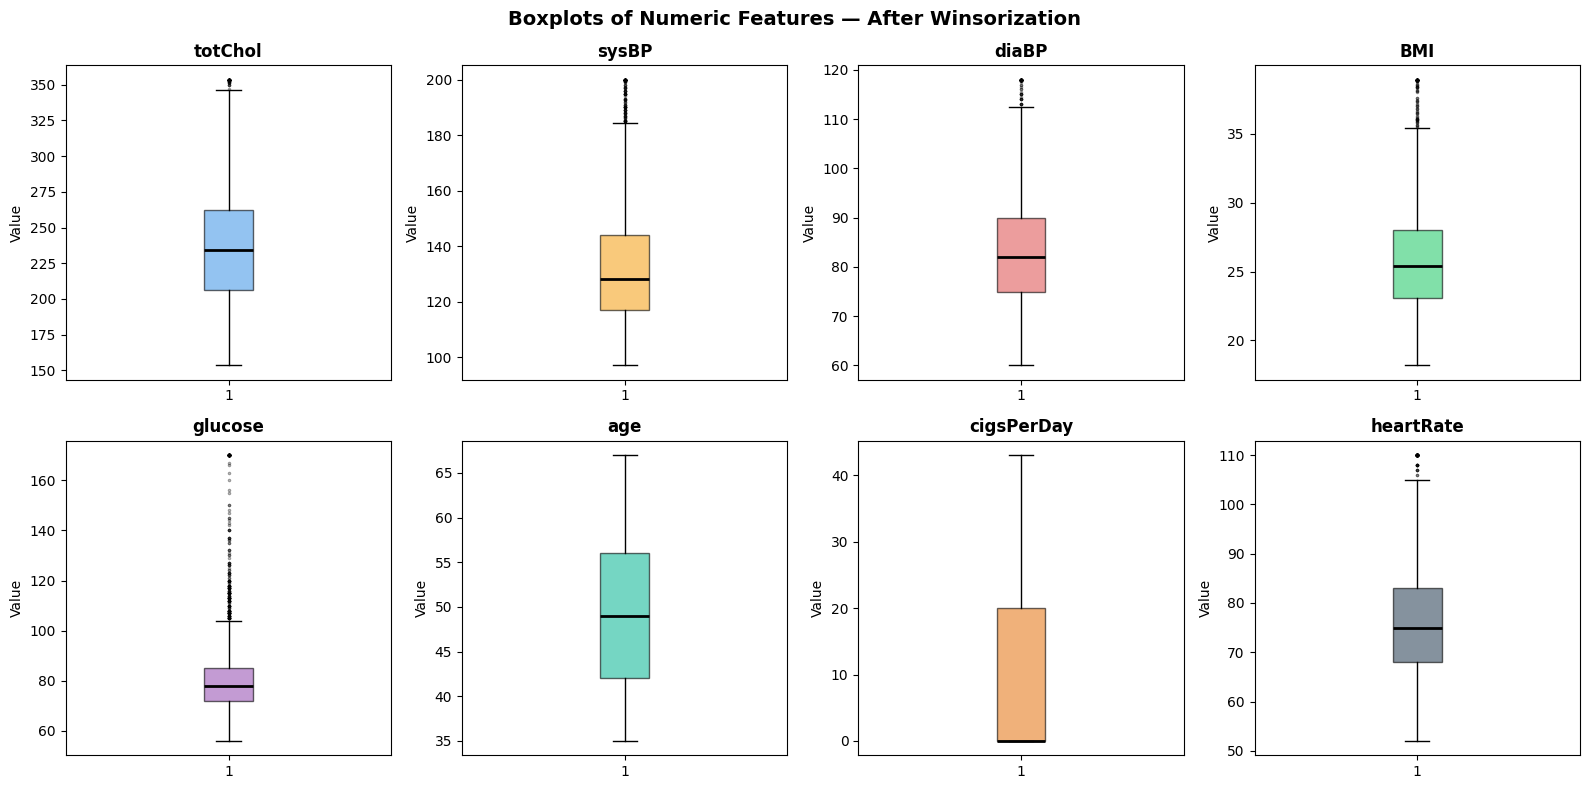

Insight: Whiskers now reflect 1st/99th percentile bounds after Winsorization.
Min/max annotations in each subplot confirm the capped value ranges.


In [143]:
# ------------------------------------------------------------------------------
# Boxplots of All Numeric Features (Post-Winsorization)
# Purpose: Visually confirm that Winsorization was applied correctly.
# After capping:
#   - Whiskers should terminate at or near the 1st/99th percentile bounds
#   - Any remaining fliers fall within clinically accepted ranges
#   - Median lines and IQR boxes remain unchanged (capping only affects extremes)
# Layout: 2×4 grid — continuous cols first, then discrete count cols
# ------------------------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Boxplots of Numeric Features — After Winsorization",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

colors = ["#4C9BE8", "#F5A623", "#E05C5C", "#2ECC71",
          "#9B59B6", "#1ABC9C", "#E67E22", "#34495E"]

for ax, col, color in zip(axes, all_numeric_cols, colors):
    ax.boxplot(df_clean_data[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               flierprops=dict(marker=".", markersize=3, alpha=0.4))
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.savefig("Visualizations/2_boxplots_post_winsorization.png", bbox_inches="tight")
plt.show()
print("Insight: Whiskers now reflect 1st/99th percentile bounds after Winsorization.")
print("Min/max annotations in each subplot confirm the capped value ranges.")

## 4. Exploratory Data Analysis (EDA)

### Target Variable Distribution
TenYearCHD is the binary outcome variable. Understanding class balance is critical before modeling.

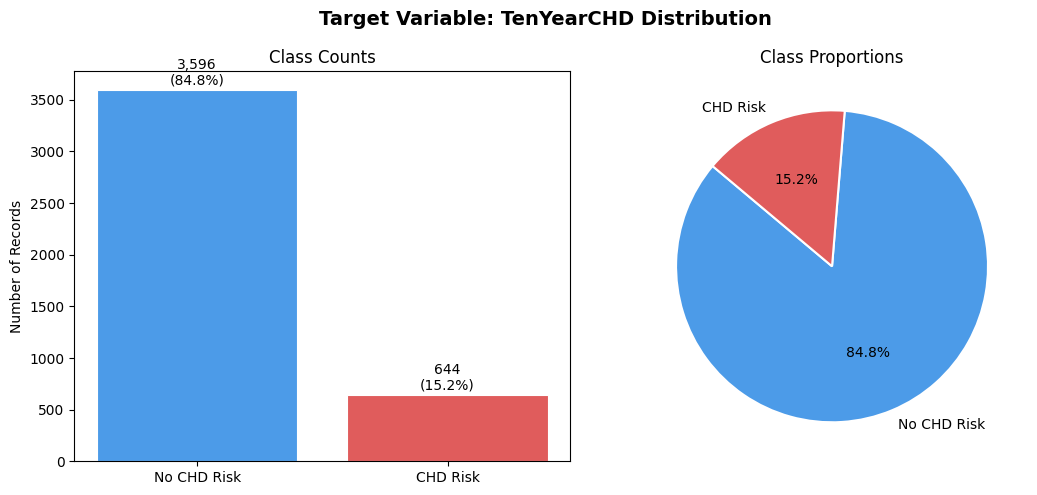

In [144]:
target_counts = df_clean_data["TenYearCHD"].value_counts()
target_labels = {0: "No CHD Risk", 1: "CHD Risk"}
target_pct = (target_counts / len(df_clean_data) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Target Variable: TenYearCHD Distribution", fontsize=14, fontweight="bold")

colors = ["#4C9BE8", "#E05C5C"]

# Bar chart
bars = axes[0].bar([target_labels[k] for k in target_counts.index],
                   target_counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Number of Records")
for bar, val, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{val:,}\n({pct}%)", ha="center", va="bottom", fontsize=10)

# Pie chart
axes[1].pie(target_counts.values,
            labels=[target_labels[k] for k in target_counts.index],
            colors=colors, autopct="%1.1f%%", startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Class Proportions")

plt.tight_layout()
plt.savefig("Visualizations/3_target_distribution.png", bbox_inches="tight")
plt.show()

### Numeric Feature Distributions (Histograms + KDE)
* Continuous features can take any real value; discrete cols are whole-number counts.
* Both benefit from skewness analysis and transformation planning

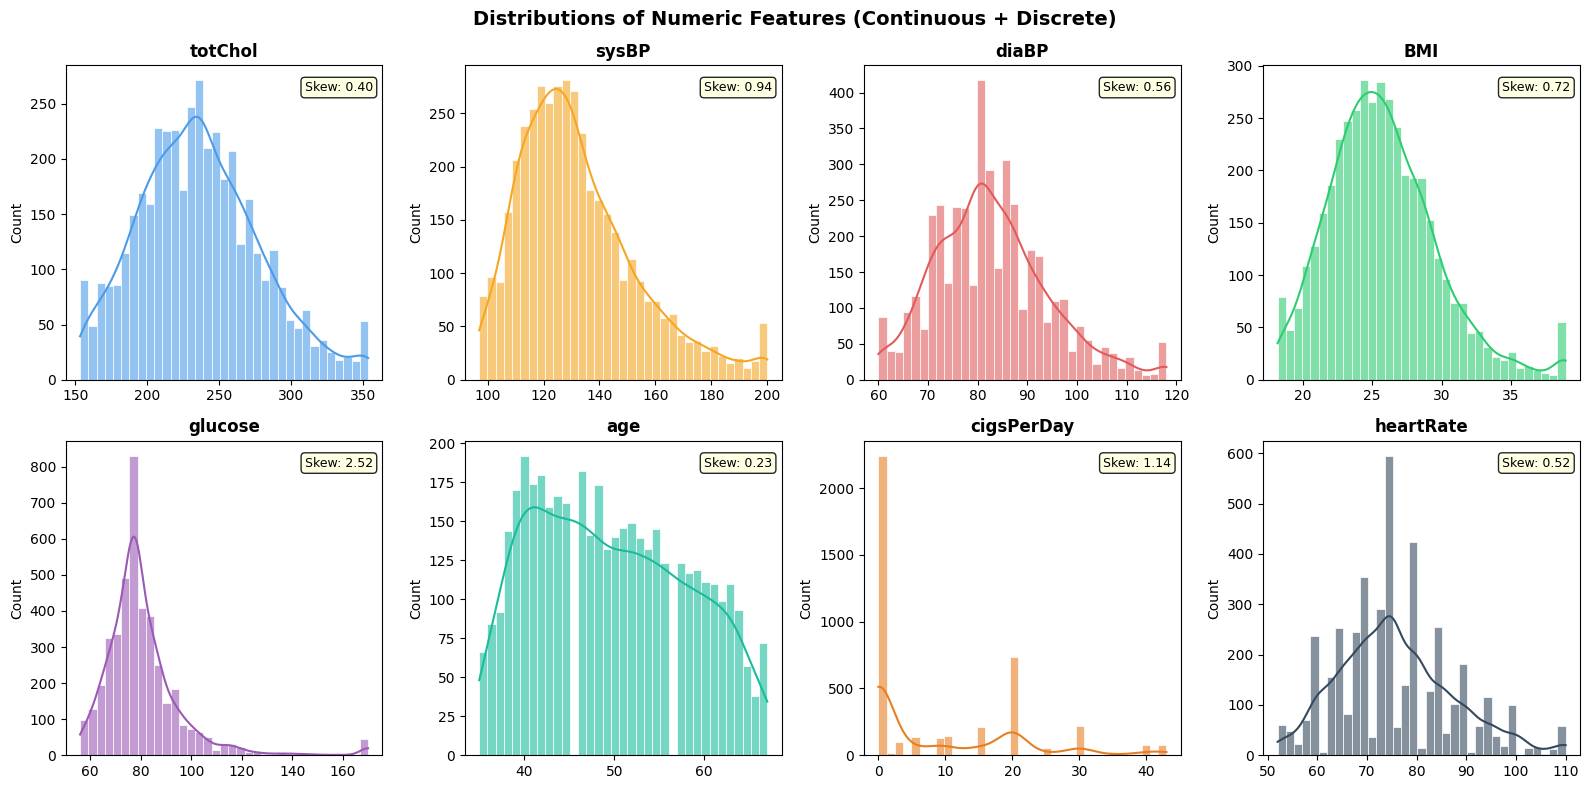


Insight: cigsPerDay and glucose are heavily right-skewed.
sysBP and diaBP are approximately normal — suitable for linear models.
=> Log or sqrt transformation planned for skewed features in Deliverable 2.


In [145]:

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Distributions of Numeric Features (Continuous + Discrete)", fontsize=14, fontweight="bold")
axes = axes.flatten()

colors = ["#4C9BE8", "#F5A623", "#E05C5C", "#2ECC71",
          "#9B59B6", "#1ABC9C", "#E67E22", "#34495E"]

for ax, col, color in zip(axes, all_numeric_cols, colors):
    sns.histplot(df_clean_data[col], bins=35, kde=True, ax=ax,
                 color=color, alpha=0.6, edgecolor="white")
    skew_val = df_clean_data[col].skew()
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.text(0.97, 0.95, f"Skew: {skew_val:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.85))

plt.tight_layout()
plt.savefig("Visualizations/4_feature_distributions.png", bbox_inches="tight")
plt.show()

print("\nInsight: cigsPerDay and glucose are heavily right-skewed.")
print("sysBP and diaBP are approximately normal — suitable for linear models.")
print("=> Log or sqrt transformation planned for skewed features in Deliverable 2.")


###  Binary & Categorical Feature Prevalence
* Shows proportion of each binary feature = 1 across the dataset
* Helps identify class imbalance in predictors

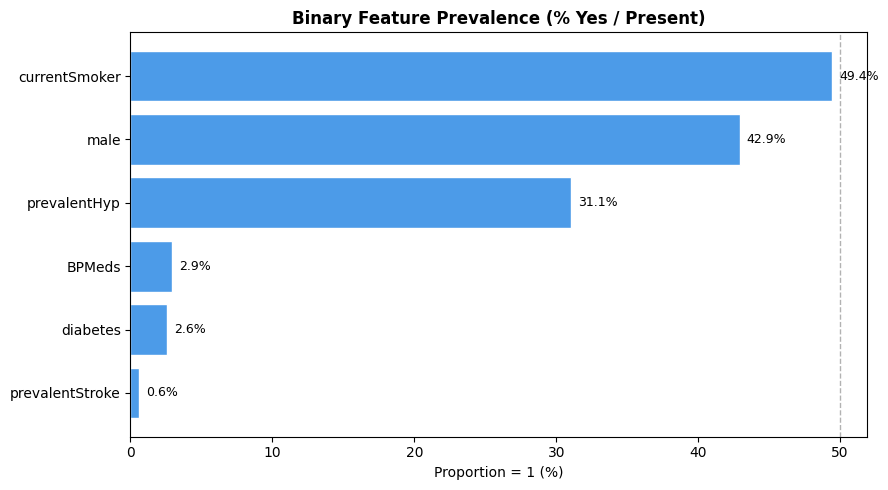


Insight: prevalentStroke (3.1%) and diabetes (2.6%) have very low prevalence.
These rare binary flags are strong candidates for association rule antecedents.
currentSmoker (49.9%) is nearly balanced — a good classification feature.


In [146]:

binary_cols = ["male", "currentSmoker", "BPMeds", "prevalentStroke",
               "prevalentHyp", "diabetes"]

prevalence = (df_clean_data[binary_cols].mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#E05C5C" if v > 50 else "#4C9BE8" for v in prevalence.values]
bars = ax.barh(prevalence.index, prevalence.values,
               color=bar_colors, edgecolor="white")
ax.axvline(50, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Proportion = 1 (%)")
ax.set_title("Binary Feature Prevalence (% Yes / Present)", fontweight="bold")
for bar, val in zip(bars, prevalence.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("Visualizations/5_binary_prevalence.png", bbox_inches="tight")
plt.show()

print("\nInsight: prevalentStroke (3.1%) and diabetes (2.6%) have very low prevalence.")
print("These rare binary flags are strong candidates for association rule antecedents.")
print("currentSmoker (49.9%) is nearly balanced — a good classification feature.")



### Numeric Features by CHD Status (Boxplots)
* Compare distributions across all numeric features (continuous + discrete)
* between CHD and no-CHD groups — large median shifts indicate strong predictors

/tmp/ipykernel_1071/2050308252.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean_data, x="CHD_Label", y=col,
/tmp/ipykernel_1071/2050308252.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean_data, x="CHD_Label", y=col,
/tmp/ipykernel_1071/2050308252.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean_data, x="CHD_Label", y=col,
/tmp/ipykernel_1071/2050308252.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

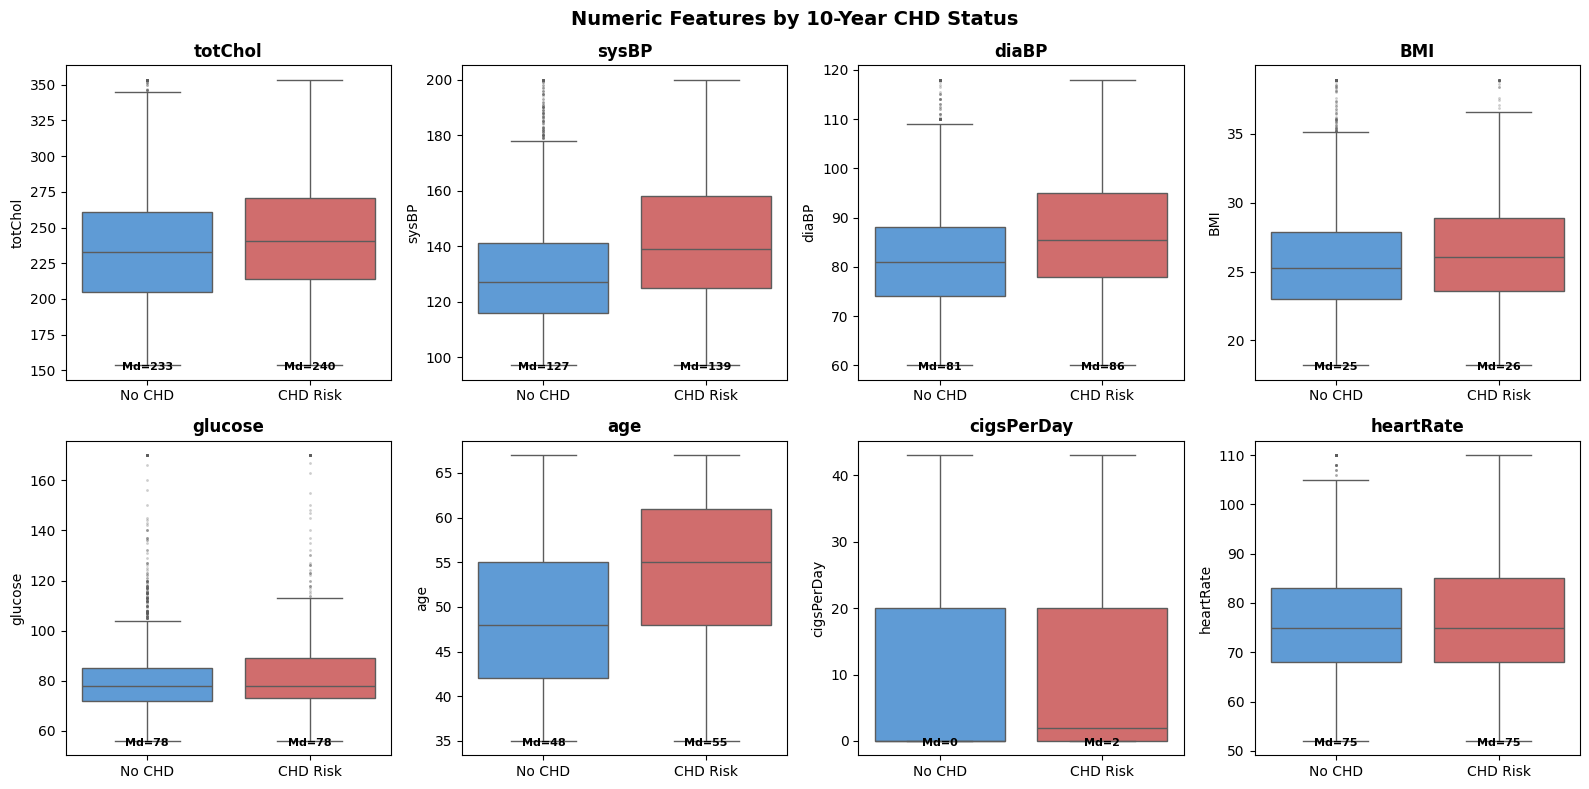


Key insights:
  age     : CHD patients are notably older (median ~53 vs ~48)
  sysBP   : Substantially higher in CHD group
  glucose : Higher median in CHD group — likely diabetes overlap
  BMI     : Slight upward shift in CHD group


In [147]:

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Numeric Features by 10-Year CHD Status", fontsize=14, fontweight="bold")
axes = axes.flatten()

palette = {0: "#4C9BE8", 1: "#E05C5C"}
df_clean_data["CHD_Label"] = df_clean_data["TenYearCHD"].map({0: "No CHD", 1: "CHD Risk"})

for ax, col in zip(axes, all_numeric_cols):
    sns.boxplot(data=df_clean_data, x="CHD_Label", y=col,
                palette={"No CHD": "#4C9BE8", "CHD Risk": "#E05C5C"},
                ax=ax, flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")

    # Annotate with median values
    for i, label in enumerate(["No CHD", "CHD Risk"]):
        med = df_clean_data[df_clean_data["CHD_Label"] == label][col].median()
        ax.text(i, ax.get_ylim()[0] + (ax.get_ylim()[1]-ax.get_ylim()[0])*0.03,
                f"Md={med:.0f}", ha="center", fontsize=8, color="black",
                fontweight="bold")

plt.tight_layout()
plt.savefig("Visualizations/6_features_by_chd.png", bbox_inches="tight")
plt.show()

print("\nKey insights:")
print("  age     : CHD patients are notably older (median ~53 vs ~48)")
print("  sysBP   : Substantially higher in CHD group")
print("  glucose : Higher median in CHD group — likely diabetes overlap")
print("  BMI     : Slight upward shift in CHD group")


### CHD Rate by Binary Risk Factors
* Quantifies how much each binary flag elevates CHD risk
* This directly informs feature selection in Deliverable 3

CHD RATE BY BINARY RISK FACTOR
                 With condition  Without condition  Risk difference
Feature                                                            
prevalentStroke            44.0               15.0             29.0
diabetes                   36.7               14.6             22.1
BPMeds                     33.1               14.7             18.4
prevalentHyp               24.7               10.9             13.8
male                       18.8               12.4              6.4
currentSmoker              15.9               14.5              1.4


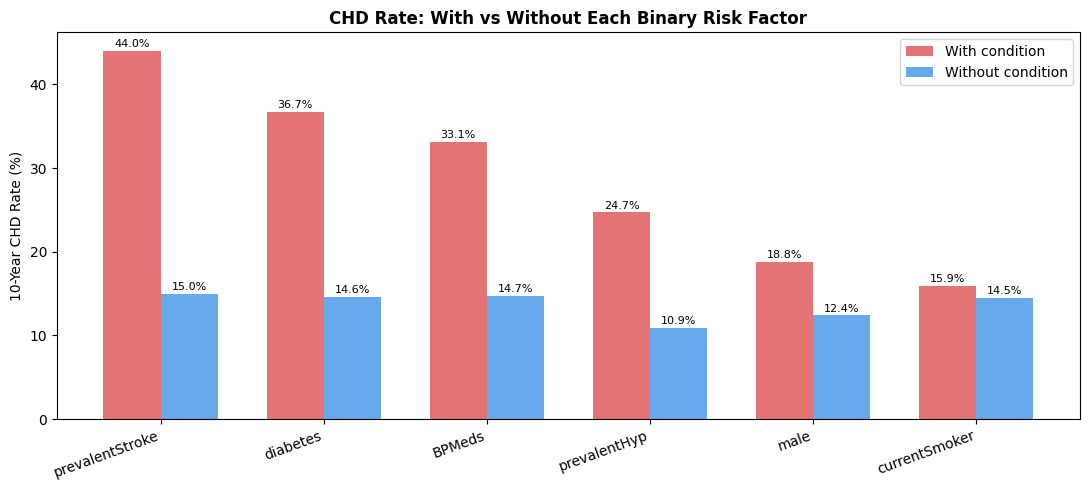

In [148]:

risk_data = []
for feat in binary_cols:
    rate_yes = df_clean_data[df_clean_data[feat] == 1]["TenYearCHD"].mean() * 100
    rate_no  = df_clean_data[df_clean_data[feat] == 0]["TenYearCHD"].mean() * 100
    risk_data.append({
        "Feature": feat,
        "With condition": round(rate_yes, 1),
        "Without condition": round(rate_no, 1),
        "Risk difference": round(rate_yes - rate_no, 1)
    })

risk_df = pd.DataFrame(risk_data).set_index("Feature").sort_values(
    "Risk difference", ascending=False)

print("CHD RATE BY BINARY RISK FACTOR")
print("=" * 55)
print(risk_df.to_string())

x = np.arange(len(risk_df))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, risk_df["With condition"],    width,
            label="With condition",    color="#E05C5C", alpha=0.85)
b2 = ax.bar(x + width/2, risk_df["Without condition"], width,
            label="Without condition", color="#4C9BE8", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(risk_df.index, rotation=20, ha="right")
ax.set_ylabel("10-Year CHD Rate (%)")
ax.set_title("CHD Rate: With vs Without Each Binary Risk Factor", fontweight="bold")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("Visualizations/7_chd_rate_by_feature.png", bbox_inches="tight")
plt.show()


### Age Distribution by CHD Status
* Age is consistently the strongest demographic predictor of CHD

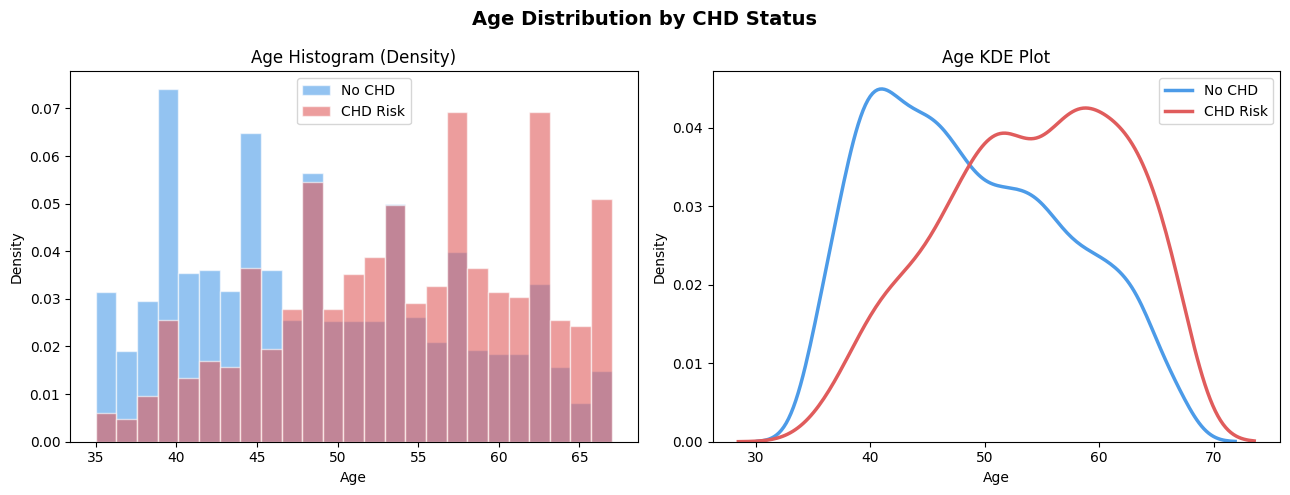


Insight: CHD risk patients skew toward older age groups (55-65).
This confirms age as one of the most important features for classification.


In [149]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Age Distribution by CHD Status", fontsize=14, fontweight="bold")

# Overlapping histograms
for label, color in [("No CHD", "#4C9BE8"), ("CHD Risk", "#E05C5C")]:
    subset = df_clean_data[df_clean_data["CHD_Label"] == label]["age"]
    axes[0].hist(subset, bins=25, alpha=0.6, label=label,
                 color=color, edgecolor="white", density=True)
axes[0].set_title("Age Histogram (Density)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Density")
axes[0].legend()

# KDE plot
for label, color in [("No CHD", "#4C9BE8"), ("CHD Risk", "#E05C5C")]:
    subset = df_clean_data[df_clean_data["CHD_Label"] == label]["age"]
    sns.kdeplot(subset, ax=axes[1], label=label, color=color, linewidth=2.5)
axes[1].set_title("Age KDE Plot")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
plt.savefig("Visualizations/8_age_by_chd.png", bbox_inches="tight")
plt.show()

print("\nInsight: CHD risk patients skew toward older age groups (55-65).")
print("This confirms age as one of the most important features for classification.")